# Task 3 – Simple Sales Dashboard Design

## Data Analytics Internship Project

**Dataset:** Sample Superstore Dataset

### Objective

Create a basic interactive sales dashboard that shows sales performance by product, region, and month.

### Dashboard KPIs

- Total Sales
- Total Profit
- Total Units Sold
- Profit Margin

### Dashboard Visualizations

- Monthly Sales Trend
- Sales by Region
- Sales by Product Category
- Top 10 Products by Sales

### Filters

- Region
- Month

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

possible_files = [
    Path("../data/cleaned/superstore_cleaned.csv"),
    Path("Sample - Superstore.csv"),
    Path("SampleSuperstore.csv"),
    Path("superstore.csv")
]

existing = next((p for p in possible_files if p.exists()), None)

if existing:
    df = pd.read_csv(existing)
    print("Loaded:", existing)
else:
    print("Dataset file not found in the current Jupyter folder.")

Loaded: ..\data\cleaned\superstore_cleaned.csv


In [3]:
from pathlib import Path

print("Current notebook working folder:")
print(Path.cwd())

print("\nFiles/folders here:")
for item in Path.cwd().iterdir():
    print(item.name)

Current notebook working folder:
C:\Users\Chetan Patil\OneDrive\Documents\Data_Analytics_Internship\Task_3_Sales_Dashboard

Files/folders here:
.ipynb_checkpoints
sales_by_category.png
sales_by_region.png
Task_3_Sales_Dashboard_Create.ipynb


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Rows: 10194
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
required_columns = [
    'Order Date',
    'Category',
    'Sub-Category',
    'Product Name',
    'Region',
    'Sales',
    'Quantity',
    'Profit'
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All dashboard columns are available.")

All dashboard columns are available.


In [6]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

print("Invalid Order Dates:", df['Order Date'].isna().sum())

Invalid Order Dates: 0


In [7]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

print("Invalid Order Dates:", df['Order Date'].isna().sum())

Invalid Order Dates: 0


In [8]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.56 %


In [9]:
total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_quantity = df['Quantity'].sum()

profit_margin = (total_profit / total_sales) * 100

print("TOTAL SALES       :", round(total_sales, 2))
print("TOTAL PROFIT      :", round(total_profit, 2))
print("TOTAL UNITS SOLD  :", total_quantity)
print("PROFIT MARGIN     :", round(profit_margin, 2), "%")

TOTAL SALES       : 2326534.35
TOTAL PROFIT      : 292296.81
TOTAL UNITS SOLD  : 38654
PROFIT MARGIN     : 12.56 %


## 4. Key Performance Indicators (KPIs)

The dashboard uses four key performance indicators to provide a quick overview of overall sales performance.

### Selected KPIs

1. **Total Sales** – Measures the total revenue generated from all sales transactions.
2. **Total Profit** – Measures the overall profit generated from the sales.
3. **Total Units Sold** – Represents the total quantity of products sold.
4. **Profit Margin** – Measures the percentage of sales revenue retained as profit.

### KPI Calculation

- **Total Sales** = Sum of Sales
- **Total Profit** = Sum of Profit
- **Total Units Sold** = Sum of Quantity
- **Profit Margin** = (Total Profit / Total Sales) × 100

These KPIs are selected because they provide stakeholders with a concise view of revenue, profitability, sales volume, and business efficiency.

## 5. Monthly Sales Performance Analysis

Monthly sales analysis is performed to understand how sales performance changes over time.

The analysis aggregates Sales, Profit, and Quantity by month. This helps identify:

- High-performing months
- Low-performing months
- Changes in sales over time
- Seasonal patterns
- Changes in profitability

A line chart will later be used to visualize the monthly sales trend.

In [10]:
# Make sure Order Date is in datetime format
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

# Create dashboard time fields
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month_name()

df['Month Number'] = df['Order Date'].dt.month

df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)

print("Date fields created successfully.")

display(
    df[
        ['Order Date', 'Year', 'Month', 'Month Number', 'Year-Month']
    ].head(10)
)

Date fields created successfully.


,Order Date,Year,Month,Month Number,Year-Month
0,2023-01-03,2023,January,1,2023-01
1,2023-01-04,2023,January,1,2023-01
2,2023-01-04,2023,January,1,2023-01
3,2023-01-04,2023,January,1,2023-01
4,2023-01-05,2023,January,1,2023-01
5,2023-01-06,2023,January,1,2023-01
6,2023-01-06,2023,January,1,2023-01
7,2023-01-06,2023,January,1,2023-01
8,2023-01-06,2023,January,1,2023-01
9,2023-01-06,2023,January,1,2023-01


In [11]:
print("Year-Month column exists:", 'Year-Month' in df.columns)
print("Number of rows:", len(df))

Year-Month column exists: True
Number of rows: 10194


In [12]:
monthly_sales = (
    df.groupby('Year-Month', as_index=False)
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Year-Month')
)

display(monthly_sales)

,Year-Month,Sales,Profit,Quantity
0,2023-01,14518.0550,2539.3907,306
1,2023-02,4519.8920,862.3084,159
2,2023-03,56933.9090,693.4499,597
3,2023-04,28295.3450,3488.8352,536
4,2023-05,26319.7670,3196.3918,504
5,2023-06,34669.4796,4999.7594,524
6,2023-07,33946.3930,-841.4826,550
7,2023-08,28918.3385,5765.2250,624
8,2023-09,82670.4288,8593.6302,1015
9,2023-10,32413.3390,3469.1749,605


In [13]:
print("Number of months:", len(monthly_sales))
print("First month:", monthly_sales['Year-Month'].min())
print("Last month:", monthly_sales['Year-Month'].max())

display(monthly_sales.head(10))

Number of months: 48
First month: 2023-01
Last month: 2026-12


,Year-Month,Sales,Profit,Quantity
0,2023-01,14518.0550,2539.3907,306
1,2023-02,4519.8920,862.3084,159
2,2023-03,56933.9090,693.4499,597
3,2023-04,28295.3450,3488.8352,536
4,2023-05,26319.7670,3196.3918,504
5,2023-06,34669.4796,4999.7594,524
6,2023-07,33946.3930,-841.4826,550
7,2023-08,28918.3385,5765.2250,624
8,2023-09,82670.4288,8593.6302,1015
9,2023-10,32413.3390,3469.1749,605


## 6. Monthly Sales Trend Visualization

The monthly sales summary is visualized using a line chart to identify changes in sales performance over time.

A line chart is appropriate because the data represents an ordered time series from January 2023 to December 2026.

The visualization helps stakeholders identify:

- Monthly sales peaks and declines
- Overall sales trends
- Seasonal patterns
- Periods requiring further investigation

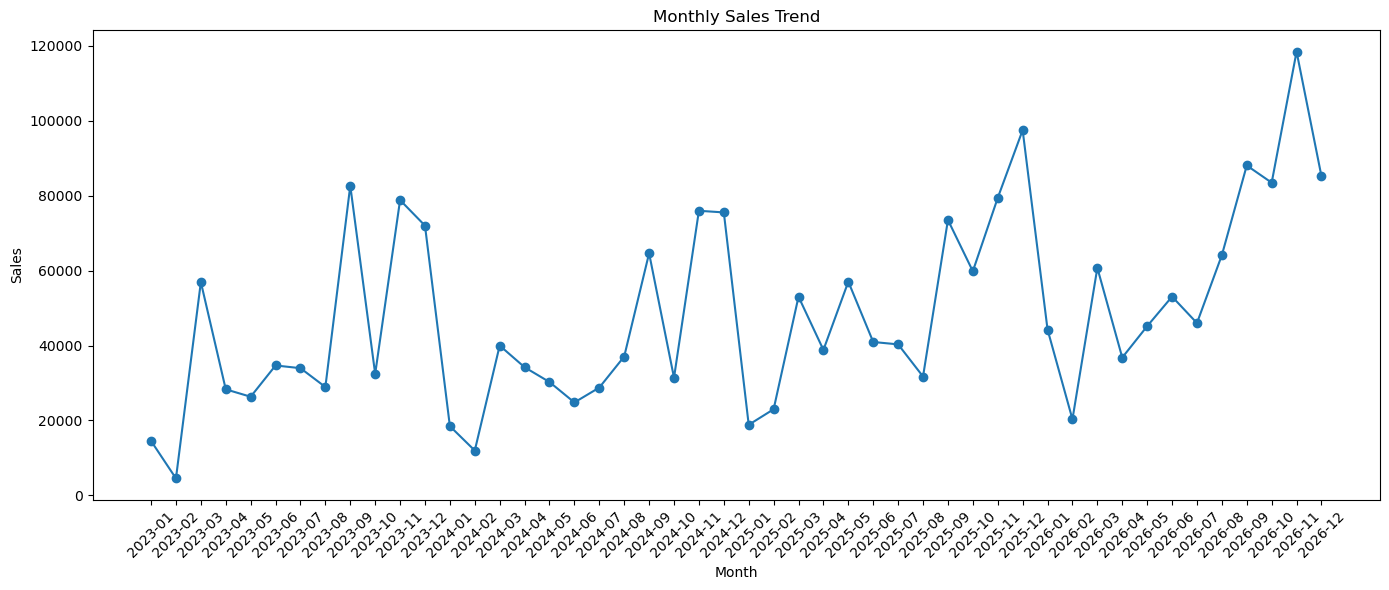

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

Monthly sales show considerable variation across the 48-month period. Some months generate substantially higher sales than others, indicating fluctuations in sales performance over time.

The monthly trend should be examined together with profit and quantity to understand whether periods of high sales also generate strong profitability.

## 7. Regional Sales Performance Analysis

Regional analysis is performed to compare sales performance across different geographic regions.

Sales, Profit, and Quantity are aggregated by Region.

This analysis helps identify:

- The region generating the highest sales
- The region generating the highest profit
- Differences in sales volume across regions
- Regions that may require additional business attention

A bar chart will be used to compare sales across regions.

In [15]:
regional_sales = (
    df.groupby('Region', as_index=False)
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Sales', ascending=False)
)

display(regional_sales)

,Region,Sales,Profit,Quantity
3,West,739813.6085,110798.8170,12466
1,East,691828.1680,94883.2603,11159
0,Central,503170.6728,39865.3070,8820
2,South,391721.9050,46749.4303,6209


In [16]:
best_sales_region = regional_sales.loc[
    regional_sales['Sales'].idxmax()
]

best_profit_region = regional_sales.loc[
    regional_sales['Profit'].idxmax()
]

print(
    "Highest Sales Region:",
    best_sales_region['Region'],
    "| Sales:",
    round(best_sales_region['Sales'], 2)
)

print(
    "Highest Profit Region:",
    best_profit_region['Region'],
    "| Profit:",
    round(best_profit_region['Profit'], 2)
)

Highest Sales Region: West | Sales: 739813.61
Highest Profit Region: West | Profit: 110798.82


### Sales by Region Visualization

A bar chart is used to compare total sales across regions. This makes it easy for stakeholders to identify the strongest and weakest regional markets.

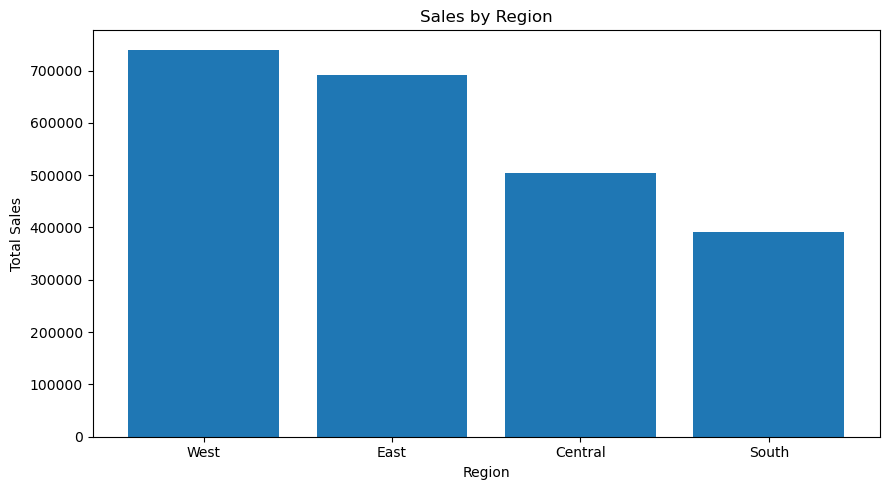

In [17]:
plt.figure(figsize=(9, 5))

plt.bar(
    regional_sales['Region'],
    regional_sales['Sales']
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

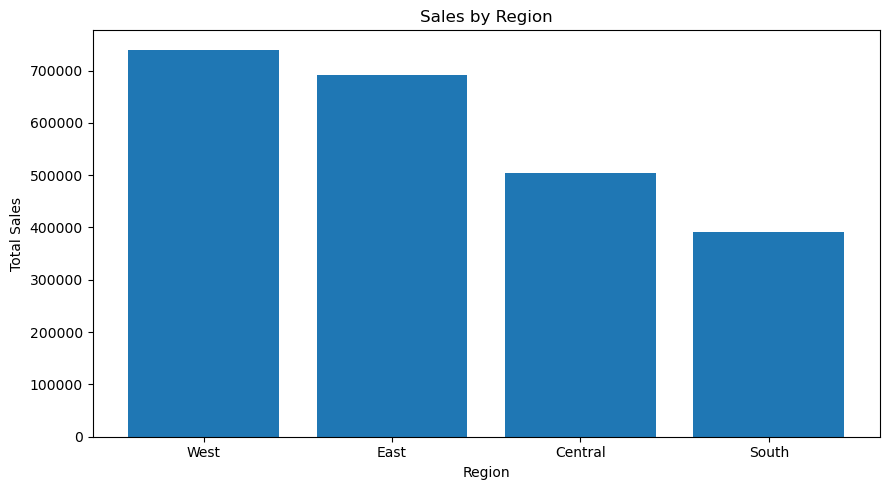

Regional sales chart saved successfully.


In [18]:
plt.figure(figsize=(9, 5))

plt.bar(
    regional_sales['Region'],
    regional_sales['Sales']
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.savefig(
    'sales_by_region.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Regional sales chart saved successfully.")

### Regional Analysis Observation

Regional sales analysis shows differences in sales performance across geographic markets.

The highest-sales region represents the strongest contributor to overall revenue, while lower-performing regions may require further investigation into customer demand, product mix, pricing, and sales strategy.

Regional performance should also be evaluated together with profit to ensure that high sales are translating into profitable business outcomes.

In [19]:
print("Number of regions:", regional_sales['Region'].nunique())

display(regional_sales)

Number of regions: 4


,Region,Sales,Profit,Quantity
3,West,739813.6085,110798.8170,12466
1,East,691828.1680,94883.2603,11159
0,Central,503170.6728,39865.3070,8820
2,South,391721.9050,46749.4303,6209


## 8. Product Category Sales Analysis

Product category analysis is performed to understand how different product categories contribute to overall sales and profit.

Sales, Profit, and Quantity are aggregated for each product category.

This analysis helps stakeholders:

- Identify the category generating the highest sales
- Compare profitability across categories
- Understand sales volume by category
- Identify categories that may require further investigation

A bar chart will be used to compare sales across product categories.

In [20]:
category_sales = (
    df.groupby('Category', as_index=False)
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Sales', ascending=False)
)

display(category_sales)

,Category,Sales,Profit,Quantity
2,Technology,839893.2790,146543.3756,7017
0,Furniture,754747.7613,19729.9956,8369
1,Office Supplies,731893.3140,126023.4434,23268


In [21]:
best_sales_category = category_sales.loc[
    category_sales['Sales'].idxmax()
]

best_profit_category = category_sales.loc[
    category_sales['Profit'].idxmax()
]

print(
    "Highest Sales Category:",
    best_sales_category['Category'],
    "| Sales:",
    round(best_sales_category['Sales'], 2)
)

print(
    "Highest Profit Category:",
    best_profit_category['Category'],
    "| Profit:",
    round(best_profit_category['Profit'], 2)
)

Highest Sales Category: Technology | Sales: 839893.28
Highest Profit Category: Technology | Profit: 146543.38


### Sales by Product Category Visualization

A bar chart is used to compare sales across product categories. The visualization allows stakeholders to quickly identify the categories contributing most to total sales.

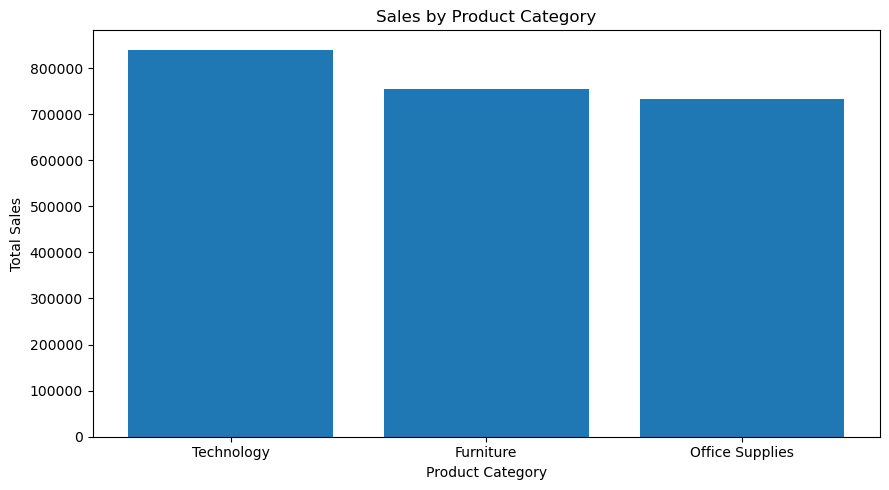

In [22]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_sales['Category'],
    category_sales['Sales']
)

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

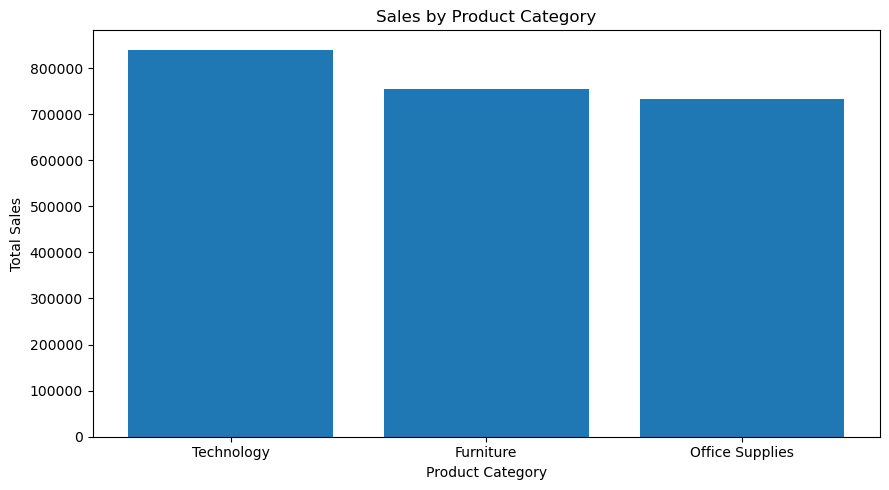

Category sales chart saved successfully.


In [23]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_sales['Category'],
    category_sales['Sales']
)

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.tight_layout()

plt.savefig(
    'sales_by_category.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Category sales chart saved successfully.")

### Category Analysis Observation

Sales performance differs across the product categories.

The highest-performing category contributes the largest share of sales, while the lower-performing categories may require additional analysis of product demand, pricing, profitability, and customer preferences.

Sales performance should be evaluated together with profit to determine whether high revenue is also generating strong business returns.

## 9. Top 10 Products by Sales

Product-level analysis is performed to identify the products generating the highest sales.

The products are ranked based on total Sales, and the top 10 products are selected for visualization.

This analysis helps stakeholders:

- Identify the products contributing most to revenue
- Understand product-level sales concentration
- Support inventory and sales planning
- Identify products that may require continued business focus

A horizontal bar chart will be used because product names can be long and are easier to compare horizontally.

In [24]:
top_products = (
    df.groupby('Product Name', as_index=False)
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Quantity=('Quantity', 'sum')
      )
      .sort_values('Sales', ascending=False)
      .head(10)
)

display(top_products)

,Product Name,Sales,Profit,Quantity
404,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03,31
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03,6
785,HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13,39
685,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
804,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03,12
682,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27
812,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,11


In [27]:
# Sort Top 10 Products for horizontal bar chart

top_products_chart = top_products.sort_values(
    'Sales',
    ascending=True
)

display(top_products_chart)

,Product Name,Sales,Profit,Quantity
812,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,11
682,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03,12
804,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
685,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
785,HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13,39
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03,6
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03,31
404,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20


### Top 10 Products by Sales Visualization

A horizontal bar chart is used to display the top 10 products by total sales.

The ranking makes it easy to identify the products that contribute the most to overall revenue.

## 10. Overall Dashboard Analysis

The analysis provides a consolidated view of sales performance across time, geographic regions, product categories, and individual products.

### Key Findings

- Total Sales are **₹2,326,534.35**.
- Total Profit is **₹292,296.81**.
- Total Units Sold are **38,654**.
- Overall Profit Margin is **12.56%**.
- The **West region** generates the highest sales among the four regions.
- The **Technology category** generates the highest sales and highest profit.
- The Top 10 Products analysis identifies the products contributing most significantly to overall sales.
- Monthly sales analysis shows variations in sales performance across the 48-month period.

These findings will be presented through an interactive dashboard to support quick business performance analysis.

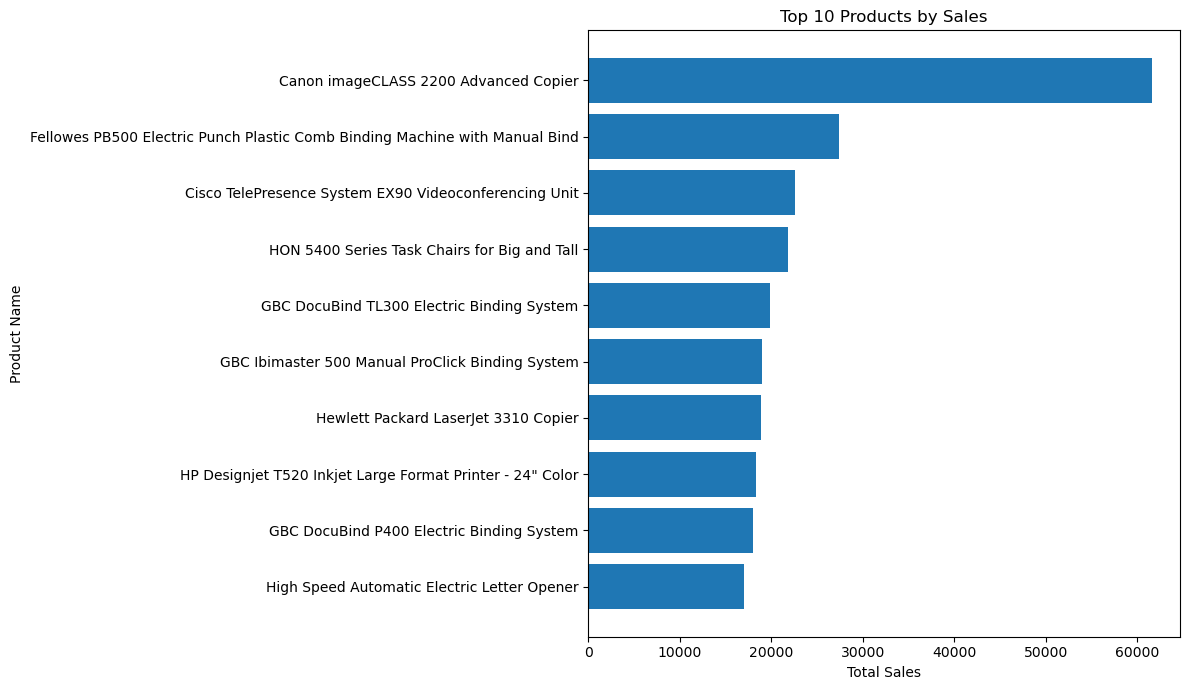

In [28]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_products_chart['Product Name'],
    top_products_chart['Sales']
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

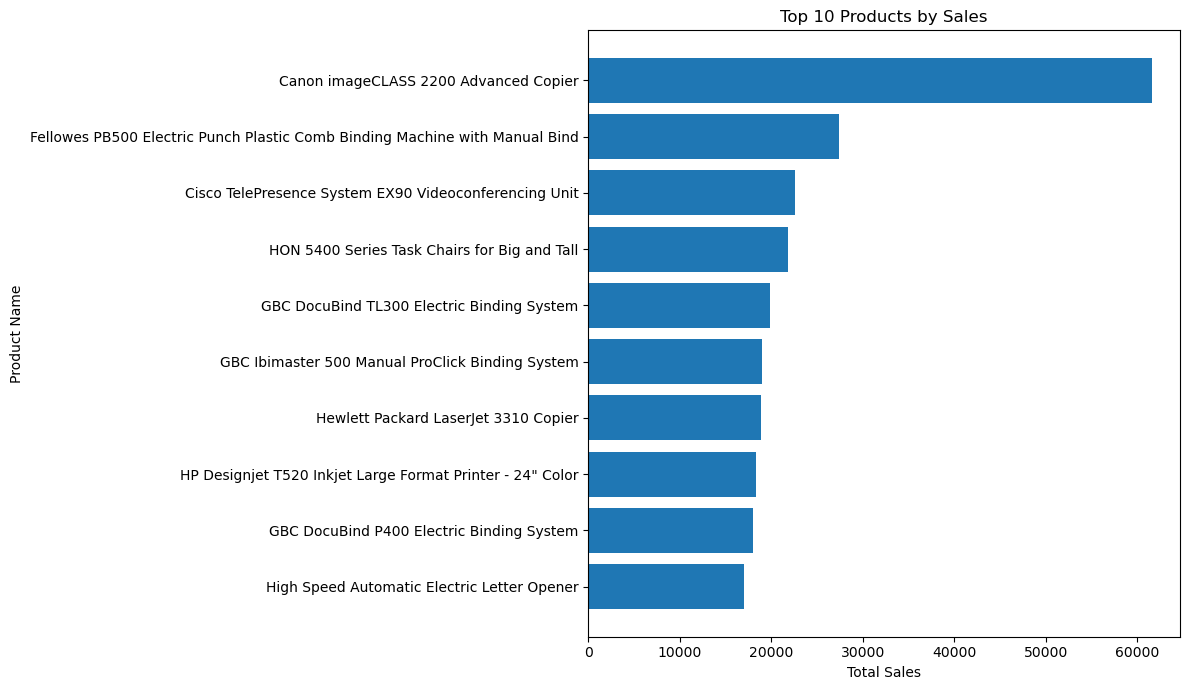

Top 10 products chart saved successfully.


In [29]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_products_chart['Product Name'],
    top_products_chart['Sales']
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.tight_layout()

plt.savefig(
    'top_10_products_by_sales.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Top 10 products chart saved successfully.")

## 11. Export Dashboard Data

The summarized KPI and sales analysis tables are exported to an Excel workbook. The workbook will be used to create the final interactive sales dashboard with charts and slicers.

In [32]:
kpi_display = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Total Profit',
        'Total Units Sold',
        'Profit Margin'
    ],
    'Value': [
        f"₹{total_sales:,.2f}",
        f"₹{total_profit:,.2f}",
        f"{total_quantity:,}",
        f"{profit_margin:.2f}%"
    ]
})

display(kpi_display)

,KPI,Value
0,Total Sales,"₹2,326,534.35"
1,Total Profit,"₹292,296.81"
2,Total Units Sold,"38,654"
3,Profit Margin,12.56%


In [33]:
dashboard_summary = {
    'Total Sales': total_sales,
    'Total Profit': total_profit,
    'Total Units Sold': total_quantity,
    'Profit Margin': profit_margin,
    'Highest Sales Region': best_sales_region['Region'],
    'Highest Sales Category': best_sales_category['Category']
}

output_file = 'Task_3_Sales_Dashboard.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    kpi_display.to_excel(writer, sheet_name='KPIs', index=False)
    monthly_sales.to_excel(writer, sheet_name='Monthly Sales', index=False)
    regional_sales.to_excel(writer, sheet_name='Regional Sales', index=False)
    category_sales.to_excel(writer, sheet_name='Category Sales', index=False)
    top_products.to_excel(writer, sheet_name='Top Products', index=False)

print("Excel dashboard data exported successfully.")
print("File:", output_file)

Excel dashboard data exported successfully.
File: Task_3_Sales_Dashboard.xlsx


In [34]:
from pathlib import Path

excel_path = Path(output_file)

print("File exists:", excel_path.exists())
print("File location:", excel_path.resolve())

File exists: True
File location: C:\Users\Chetan Patil\OneDrive\Documents\Data_Analytics_Internship\Task_3_Sales_Dashboard\Task_3_Sales_Dashboard.xlsx


In [35]:
excel_file = pd.ExcelFile(output_file)

print("Excel sheets:")
print(excel_file.sheet_names)

Excel sheets:
['KPIs', 'Monthly Sales', 'Regional Sales', 'Category Sales', 'Top Products']
